In [11]:
#imports

import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import pickle
import csv

SEED = 67
# :)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Cell 1 - OK")

Cell 1 - OK


In [12]:
# load

transform = transforms.Compose([

    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Download the training data
train_data = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)


# download the test data
test_data = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# creata data loaders
train_loader = DataLoader(
    train_data,
    batch_size=64,
    shuffle=True
)


test_loader = DataLoader(
    test_data,
    batch_size=64,
    shuffle=False
    )


class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Training images: {len(train_data)}")
print(f"Test images: {len(test_data)}")
print(f"Batches in training loader: {len(train_loader)}")
print(f"Classes: {class_names}")

Training images: 60000
Test images: 10000
Batches in training loader: 938
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


Image batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])
Pixel value range: -1.00 to 1.00


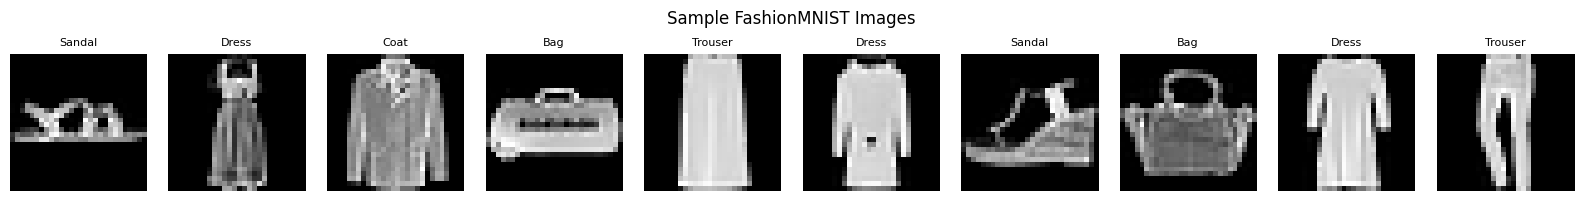

You can see the clothing images above!


In [13]:
# visualize the data

images, labels = next(iter(train_loader))

print(f"Image batch shape: {images.shape}")
print(f"Labels batch shape: {labels.shape}")
print(f"Pixel value range: {images.min():.2f} to {images.max():.2f}")

fig, axes = plt.subplots(1, 10, figsize=(16, 2))
for i in range(10):
    axes[i].imshow(
        images[i].squeeze(),
        cmap='gray'
    )
    axes[i].set_title(class_names[labels[i]], fontsize=8)
    axes[i].axis('off')

plt.suptitle('Sample FashionMNIST Images', fontsize=12)
plt.tight_layout()
plt.show()
print("You can see the clothing images above!")

In [14]:
# build the model

class FashionNet(nn.Module):


    def __init__(self):
        super(FashionNet, self).__init__()
        self.network = nn.Sequential(


            nn.Flatten(),                #layer 1- flatten
            nn.Linear(784, 256),         #layer 2-first linear layer
            nn.ReLU(),                   #layer 3-relu activation
            nn.Linear(256, 128),         # layer 4- second linear layer
            nn.ReLU(),                   #layer 5- relu activation
            nn.Linear(128, 10)           #layer 6- output layer

        )

    def forward(self, x):

        return self.network(x)


# Create an instance of our model
model = FashionNet()

print(model)
print()

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")


FashionNet(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total trainable parameters: 235,146


In [15]:
#loss function
criterion = nn.CrossEntropyLoss()

#optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)


print("Loss function:", criterion)
print("Optimizer: Adam with lr=0.001")
print("Ready to train!")

Loss function: CrossEntropyLoss()
Optimizer: Adam with lr=0.001
Ready to train!


In [16]:
# training loop

epochs = 10


train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:


        optimizer.zero_grad()                    # S1 : zero gradient
        outputs = model(images)                  #S2 :forward pass
        loss = criterion(outputs, labels)        #S3 : calculate loss
        loss.backward()                          #S4 : backward pass
        optimizer.step()                         #S5 : update weigths


        running_loss += loss.item()


        _, predicted = torch.max(outputs, dim=1)


        total += labels.size(0)


        correct += (predicted == labels).sum().item()


    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = correct / total
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    #  validation part
    model.eval()


    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in test_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, dim=1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / len(test_loader)
    epoch_val_acc = val_correct / val_total
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    print(f"Epoch [{epoch+1:2d}/{epochs}] | "
          f"Train Loss: {epoch_train_loss:.4f} | "
          f"Train Acc: {epoch_train_acc*100:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f} | "
          f"Val Acc: {epoch_val_acc*100:.2f}%")

print("\nTraining complete!")
print(f"Final Validation Accuracy: {val_accuracies[-1]*100:.2f}%")

Epoch [ 1/10] | Train Loss: 0.4950 | Train Acc: 81.99% | Val Loss: 0.4219 | Val Acc: 84.72%
Epoch [ 2/10] | Train Loss: 0.3657 | Train Acc: 86.60% | Val Loss: 0.4070 | Val Acc: 84.89%
Epoch [ 3/10] | Train Loss: 0.3306 | Train Acc: 87.81% | Val Loss: 0.3746 | Val Acc: 86.72%
Epoch [ 4/10] | Train Loss: 0.3054 | Train Acc: 88.65% | Val Loss: 0.3481 | Val Acc: 87.50%
Epoch [ 5/10] | Train Loss: 0.2836 | Train Acc: 89.46% | Val Loss: 0.3513 | Val Acc: 87.13%
Epoch [ 6/10] | Train Loss: 0.2682 | Train Acc: 90.01% | Val Loss: 0.3425 | Val Acc: 87.53%
Epoch [ 7/10] | Train Loss: 0.2544 | Train Acc: 90.48% | Val Loss: 0.3684 | Val Acc: 86.89%
Epoch [ 8/10] | Train Loss: 0.2436 | Train Acc: 90.82% | Val Loss: 0.3333 | Val Acc: 88.44%
Epoch [ 9/10] | Train Loss: 0.2294 | Train Acc: 91.44% | Val Loss: 0.3373 | Val Acc: 88.20%
Epoch [10/10] | Train Loss: 0.2215 | Train Acc: 91.57% | Val Loss: 0.3393 | Val Acc: 88.51%

Training complete!
Final Validation Accuracy: 88.51%


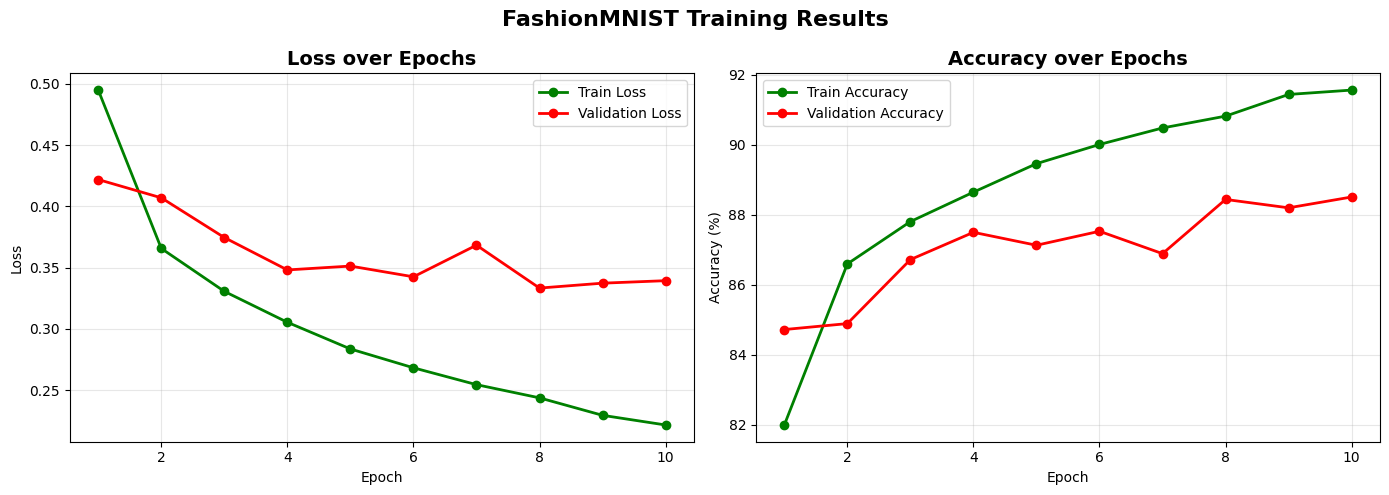

In [17]:
# graph plotting


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))


epoch_range = range(1, epochs + 1)

# loss
ax1.plot(epoch_range, train_losses, 'g-o', label='Train Loss', linewidth=2)
ax1.plot(epoch_range, val_losses, 'r-o', label='Validation Loss', linewidth=2)

ax1.set_title('Loss over Epochs', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# accuracy
ax2.plot(epoch_range, [a*100 for a in train_accuracies],
         'g-o', label='Train Accuracy', linewidth=2)
ax2.plot(epoch_range, [a*100 for a in val_accuracies],
         'r-o', label='Validation Accuracy', linewidth=2)
ax2.set_title('Accuracy over Epochs', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('FashionMNIST Training Results', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('training_plot.png', dpi=150, bbox_inches='tight')
plt.show()


In [18]:
#  generate sub.csv and save

model_state = model.state_dict()

with open('model_weights.pkl', 'wb') as f:

    pickle.dump(model_state, f)


print("Model saved to model_weights.pkl")


with open('model_weights.pkl', 'rb') as f:

    loaded_weights = pickle.load(f)


print(f"Verified: loaded {len(loaded_weights)} parameter tensors")
print("Parameter keys:", list(loaded_weights.keys()))

# submission.csv
model.eval()
all_predictions = []

with torch.no_grad():
    for images, _ in test_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs, dim=1)


        all_predictions.extend(predicted.tolist())


print(f"\nGenerated {len(all_predictions)} predictions")

# write
with open('submission.csv', 'w', newline='') as f:

    writer = csv.writer(f)
    writer.writerow(['Id', 'Label'])
    for idx, label in enumerate(all_predictions):
        writer.writerow([idx, label])

print("submission.csv saved!")
print("\nSample predictions:")
for i in range(5):
    print(f"  Image {i}: predicted '{class_names[all_predictions[i]]}'")

Model saved to model_weights.pkl
Verified: loaded 6 parameter tensors
Parameter keys: ['network.1.weight', 'network.1.bias', 'network.3.weight', 'network.3.bias', 'network.5.weight', 'network.5.bias']

Generated 10000 predictions
submission.csv saved!

Sample predictions:
  Image 0: predicted 'Ankle boot'
  Image 1: predicted 'Pullover'
  Image 2: predicted 'Trouser'
  Image 3: predicted 'Trouser'
  Image 4: predicted 'Shirt'


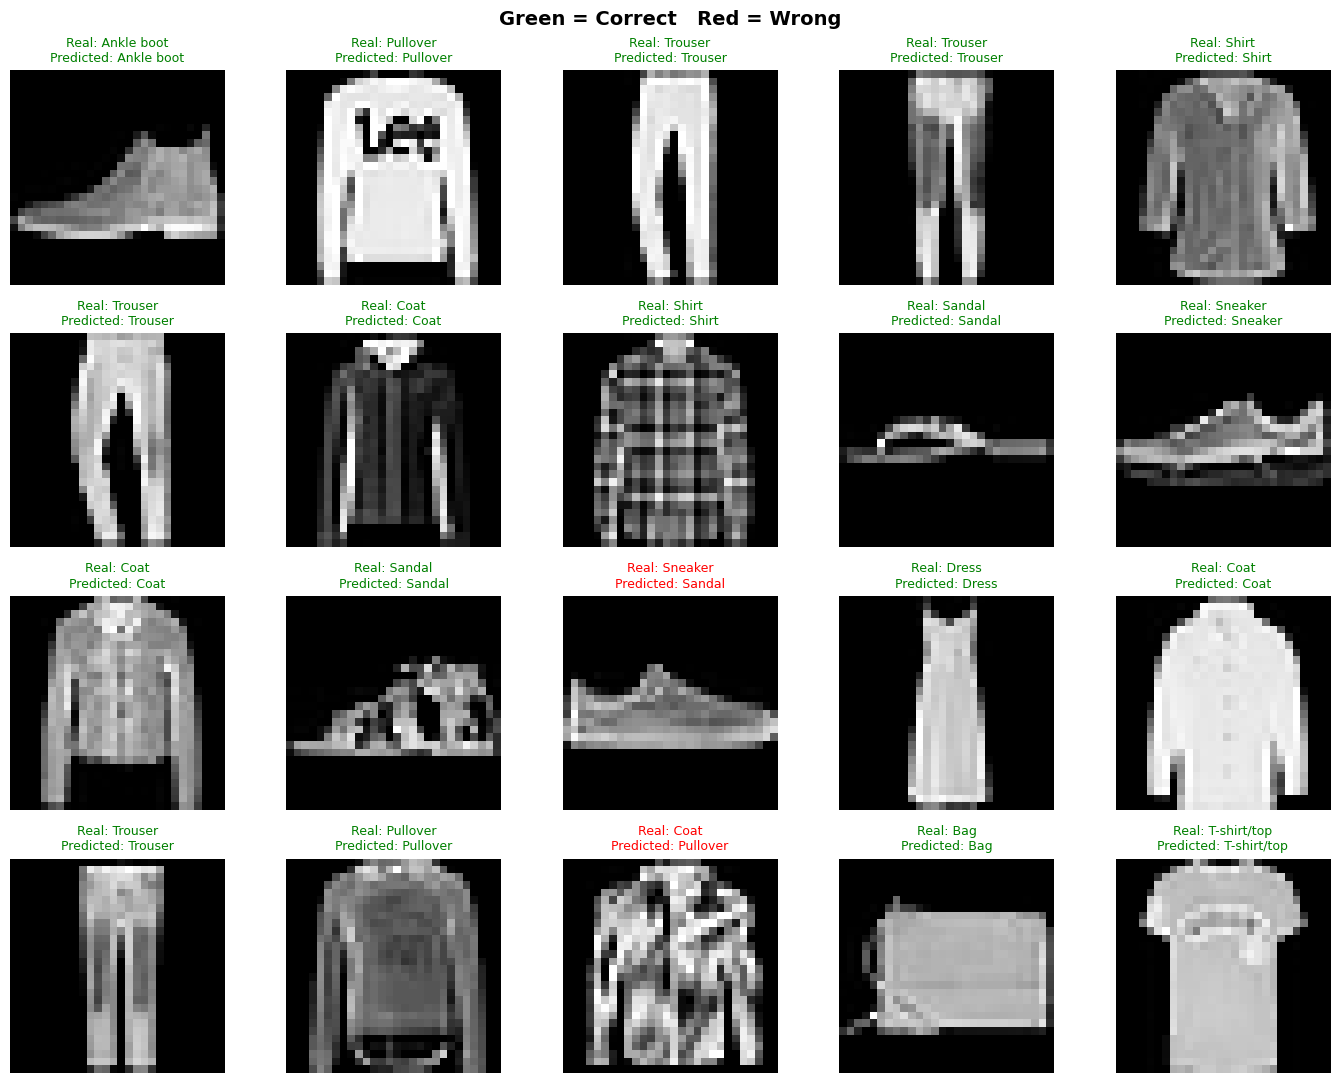

In [19]:
# vizialize predictions

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

model.eval()


test_images, test_labels = next(iter(test_loader))

with torch.no_grad():
    outputs = model(test_images)
    _, predicted = torch.max(outputs, dim=1)


fig, axes = plt.subplots(4, 5, figsize=(14, 11))
axes = axes.flatten()

for i in range(20):
    image = test_images[i].squeeze().numpy()
    true_label = class_names[test_labels[i]]
    pred_label = class_names[predicted[i]]
    correct = (true_label == pred_label)

    axes[i].imshow(image, cmap='gray')


    color = 'green' if correct else 'red'
    axes[i].set_title(
        f"Real: {true_label}\nPredicted: {pred_label}",
        color=color,
        fontsize=9
    )
    axes[i].axis('off')

plt.suptitle('Green = Correct   Red = Wrong', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('predictions_visual.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
from google.colab import files
files.download('training_plot.png')
files.download('model_weights.pkl')
files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>